In [2]:
import pandas as pd
import numpy as np
import cv2
import os

In [3]:
train_dir = os.path.join(os.getcwd(),r'/content/drive/MyDrive/archive (2)/train')
test_dir=os.path.join(os.getcwd(),r'/content/drive/MyDrive/archive (2)/test')
categories=['benign', 'malignant']
y_train=[]
x_train=[]
x_test = []
y_test=[]
Batch_Size=32
INIT_LR=1e-4
EPOCHES=10

In [4]:
for category in categories:
  path=os.path.join(train_dir,category)
  for img in os.listdir(path):
    img_path=os.path.join(path, img)
    image=cv2.imread(img_path)
    image=cv2.resize(image, (224,224))
    image=image/255
    x_train.append(image)
    y_train.append(category)

In [5]:
for category in categories:
  path=os.path.join(test_dir,category)
  for img in os.listdir(path):
    img_path=os.path.join(path,img)
    image=cv2.imread(img_path)
    image=cv2.resize(image, (224,224))
    image=image/255
    x_test.append(image)
    y_test.append(category)

In [6]:
from sklearn.preprocessing import LabelBinarizer
from keras.utils import to_categorical
lb=LabelBinarizer()
y_train=lb.fit_transform(y_train)
y_train=to_categorical(y_train, num_classes=2)
y_test=lb.fit_transform(y_test)
y_test=to_categorical(y_test,num_classes=2)

In [8]:
x_train=np.array(x_train, dtype='float32')
y_train= np.array(y_train, dtype='float32')
x_test= np.array(x_test,dtype='float32')
y_test=np.array(y_test, dtype='float32')

In [9]:
from keras.layers import Dense, Flatten, MaxPool2D, Dropout, Conv2D, InputLayer
from keras.models import Sequential
model=Sequential()
model.add(InputLayer(input_shape=(224,224,3)))
model.add(Conv2D(32, kernel_size=(2,2), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(2,2), activation='relu'))
model.add (MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(128, kernel_size=(2,2), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dropout(.5))
model.add(Dense(2, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [10]:
from keras.optimizers import Adam
#Regularization
opt=Adam(learning_rate=INIT_LR,weight_decay=INIT_LR/Batch_Size)

In [11]:
model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

In [12]:
History=model.fit(
  x_train,
  y_train,
  epochs=EPOCHES,
  steps_per_epoch=len(x_train)//Batch_Size,
  batch_size=Batch_Size,
  validation_steps=.2)

Epoch 1/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.6277 - loss: 0.6493
Epoch 2/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 258us/step - accuracy: 0.6400 - loss: 0.6393
Epoch 3/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


82/82 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.7439 - loss: 0.5299
Epoch 4/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 334us/step - accuracy: 0.6000 - loss: 0.5654
Epoch 5/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.7675 - loss: 0.4783
Epoch 6/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 326us/step - accuracy: 0.9200 - loss: 0.3363
Epoch 7/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 206s 2s/step - accuracy: 0.7824 - loss: 0.4591
Epoch 8/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 560us/step - accuracy: 0.9200 - loss: 0.3639
Epoch 9/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step - accuracy: 0.7778 - loss: 0.4520
Epoch 10/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 226us/step - accuracy: 0.9200 - loss: 0.3658


In [13]:
pred_result=model.predict(x_test,batch_size=Batch_Size)
pred_result = np.argmax(pred_result, axis=1)

21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 415ms/step


In [14]:
from sklearn.metrics import classification_report
print(f"Classifiation Report:\n {classification_report(y_test.argmax(axis=1), pred_result, target_names=lb.classes_)}")

Classifiation Report:
               precision    recall  f1-score   support

      benign       0.78      0.77      0.78       360
   malignant       0.73      0.74      0.74       300

    accuracy                           0.76       660
   macro avg       0.76      0.76      0.76       660
weighted avg       0.76      0.76      0.76       660



In [15]:
model.save('model.h5')

In [16]:
import matplotlib.pyplot as plt
%matplotlib inline

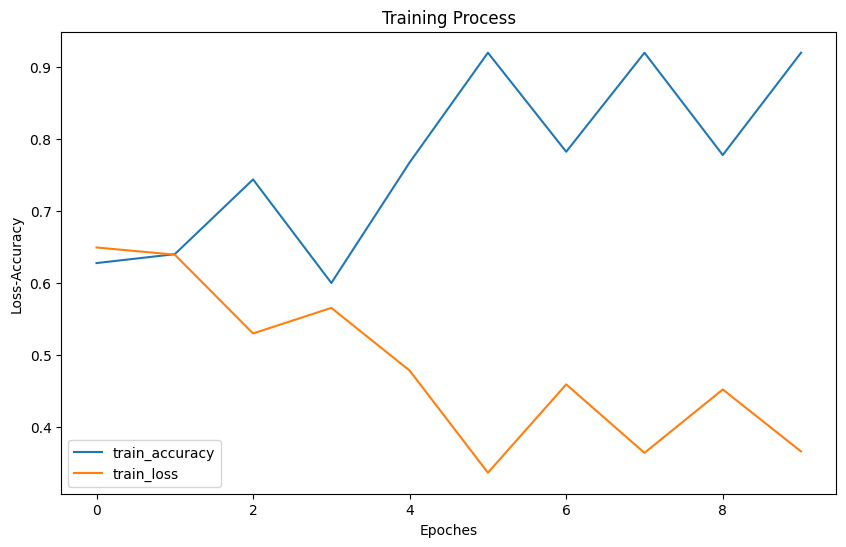

In [17]:
plt.figure(figsize=(10,6))
plt.plot(np.arange(0,10), History.history['accuracy'], label='train_accuracy')
plt.plot(np.arange(0,10), History.history['loss'], label='train_loss')
plt.xlabel('Epoches')
plt.ylabel('Loss-Accuracy')
plt.title('Training Process')
plt.legend(loc='lower left')
plt.show()

In [33]:
sample_dir=r"/content/drive/MyDrive/archive (2)/data/train/benign"
prediction=[]
class_index= []
for img in os.listdir(sample_dir):
  image_path = os.path.join(sample_dir,img)
  image_sample=cv2.imread(image_path)
  img_array=cv2.resize(image_sample, (224,224))
  img_array=img_array / 255.0
  img_array=np.array([img_array], dtype='float32')
  pred=model.predict(img_array)
  prediction.append(pred)
  class_index.append(pred.argmax(axis=1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━

In [34]:
class_type=lb.classes_[class_index]
class_type

array([['benign'],
       ['benign'],
       ['benign'],
       ...,
       ['benign'],
       ['benign'],
       ['malignant']], dtype='<U9')

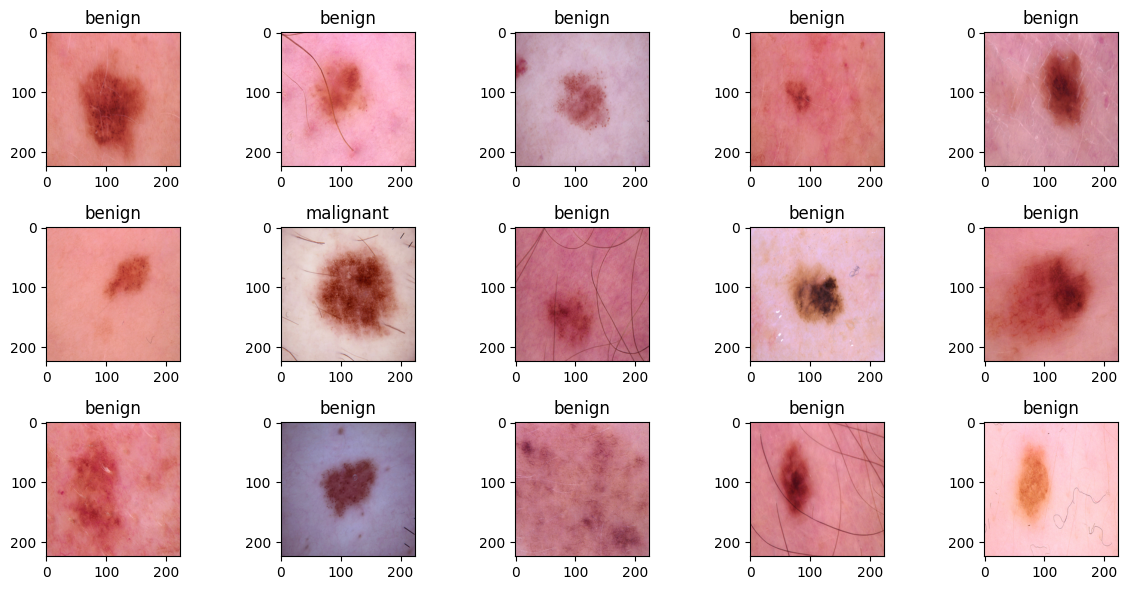

In [39]:
from keras.preprocessing.image import load_img
plt.figure(figsize=(12,6))
for i, img in enumerate(os.listdir(sample_dir)[:15]):
  img_path=os.path.join(sample_dir,img)
  image = load_img(img_path, target_size=(224,224))
  plt.subplot(3,5,i+1)
  plt.imshow(image)
  plt.title(*class_type[i])
plt.tight_layout()
plt.show()